In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("bookings.csv")

df.head()


,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
0,Resort Hotel,Direct,No Deposit,342,0,0,0,3,0,0
1,Resort Hotel,Direct,No Deposit,737,0,0,0,4,0,0
2,Resort Hotel,Direct,No Deposit,7,0,0,0,0,0,0
3,Resort Hotel,Corporate,No Deposit,13,0,0,0,0,0,0
4,Resort Hotel,Online TA,No Deposit,14,0,0,0,0,1,0


In [3]:
df.shape

(119390, 10)

In [4]:
df.columns

Index(['hotel', 'market_segment', 'deposit_type', 'lead_time',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'days_in_waiting_list', 'booking_changes', 'total_of_special_requests',
       'is_canceled'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   hotel                           119390 non-null  str  
 1   market_segment                  119390 non-null  str  
 2   deposit_type                    119390 non-null  str  
 3   lead_time                       119390 non-null  int64
 4   previous_cancellations          119390 non-null  int64
 5   previous_bookings_not_canceled  119390 non-null  int64
 6   days_in_waiting_list            119390 non-null  int64
 7   booking_changes                 119390 non-null  int64
 8   total_of_special_requests       119390 non-null  int64
 9   is_canceled                     119390 non-null  int64
dtypes: int64(7), str(3)
memory usage: 12.5 MB


In [6]:
df.describe()

,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.087118,0.137097,2.321149,0.221124,0.571363,0.370416
std,106.863097,0.844336,1.497437,17.594721,0.652306,0.792798,0.482918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,160.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,737.000000,26.000000,72.000000,391.000000,21.000000,5.000000,1.000000


In [7]:
df.describe(include='object')

C:\Users\aniru\AppData\Local\Temp\ipykernel_26276\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,hotel,market_segment,deposit_type
count,119390,119390,119390
unique,2,8,3
top,City Hotel,Online TA,No Deposit
freq,79330,56477,104641


In [8]:
df.sample(5)

,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
81527,City Hotel,Offline TA/TO,No Deposit,8,0,0,0,0,0,0
69184,City Hotel,Groups,Non Refund,168,0,0,0,0,0,1
50872,City Hotel,Online TA,No Deposit,27,0,0,0,0,0,1
72944,City Hotel,Online TA,No Deposit,125,0,0,0,0,0,1
45663,City Hotel,Groups,No Deposit,140,0,0,87,2,0,0


In [9]:
df.isnull().sum()

hotel                             0
market_segment                    0
deposit_type                      0
lead_time                         0
previous_cancellations            0
previous_bookings_not_canceled    0
days_in_waiting_list              0
booking_changes                   0
total_of_special_requests         0
is_canceled                       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(98046)

In [11]:
df.dtypes

hotel                               str
market_segment                      str
deposit_type                        str
lead_time                         int64
previous_cancellations            int64
previous_bookings_not_canceled    int64
days_in_waiting_list              int64
booking_changes                   int64
total_of_special_requests         int64
is_canceled                       int64
dtype: object

## Start EDA

We'll begin with Univariate Analysis.

In [12]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [13]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [14]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [15]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

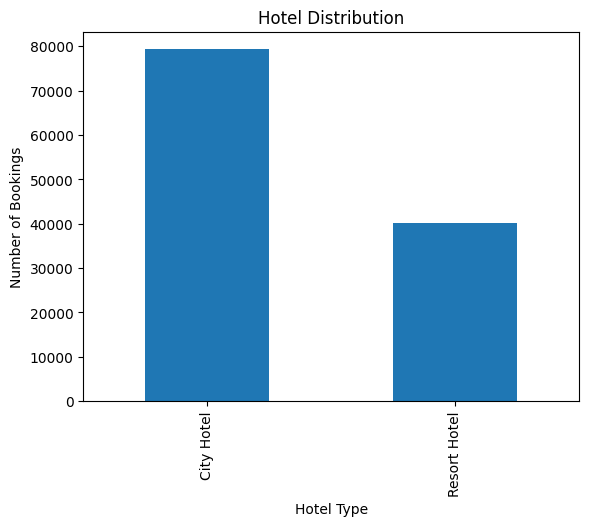

In [16]:
df['hotel'].value_counts().plot(kind='bar')

plt.title('Hotel Distribution')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

### interpretation
City Hotel receives more bookings than Resort Hotel.
Most customers prefer City Hotels.
Marketing efforts may be focused on the hotel type with lower bookings.

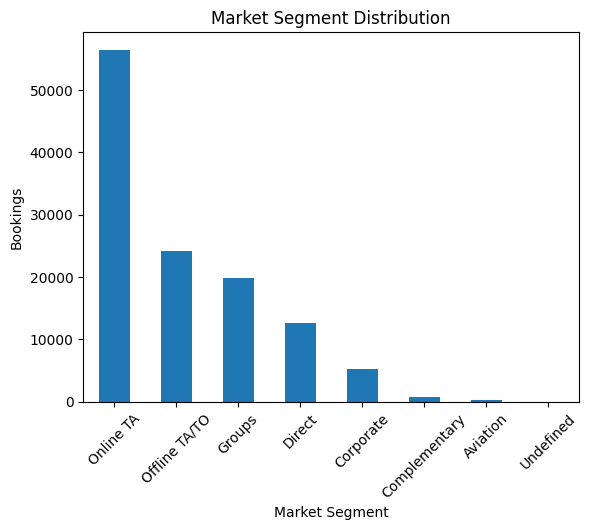

In [17]:
df['market_segment'].value_counts().plot(kind='bar')

plt.title('Market Segment Distribution')
plt.xlabel('Market Segment')
plt.ylabel('Bookings')
plt.xticks(rotation=45)
plt.show()

### Interpretation
the segment with maximum bookings.

- Online Travel Agents (OTA) contribute the highest number of bookings.
- Corporate bookings contribute a smaller share.
- OTA partnerships are important for revenue generation.

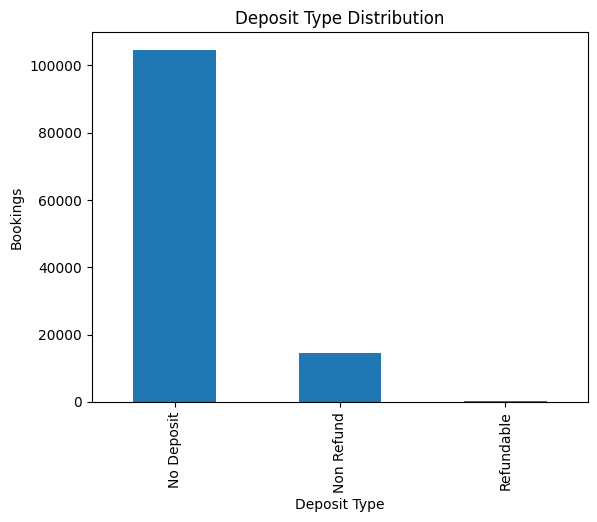

In [18]:
df['deposit_type'].value_counts().plot(kind='bar')

plt.title('Deposit Type Distribution')
plt.xlabel('Deposit Type')
plt.ylabel('Bookings')
plt.show()

### Interpretation

- Most customers prefer No Deposit bookings.
- Very few customers make Non-Refund deposits.
- Flexible booking policies appear more popular.

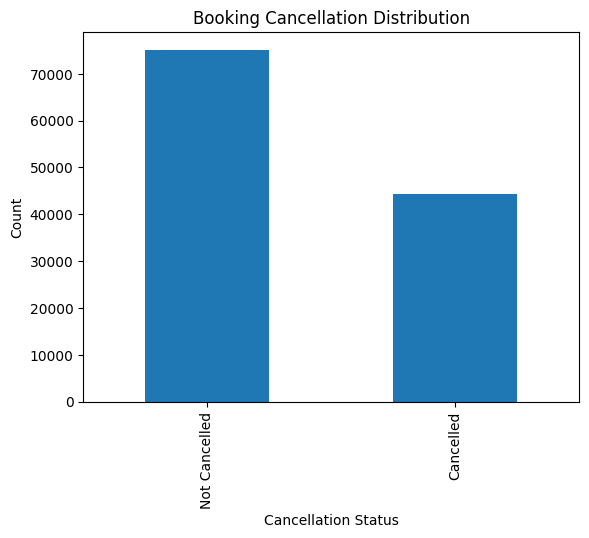

In [20]:
df['is_canceled'].replace({0:'Not Cancelled',1:'Cancelled'}).value_counts().plot(kind='bar')
plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Count')
plt.show()

### Interpretation

A significant percentage of bookings are cancelled.
Cancellation management can improve hotel revenue.
Understanding cancellation drivers will be a key focus of analysis.

In [23]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

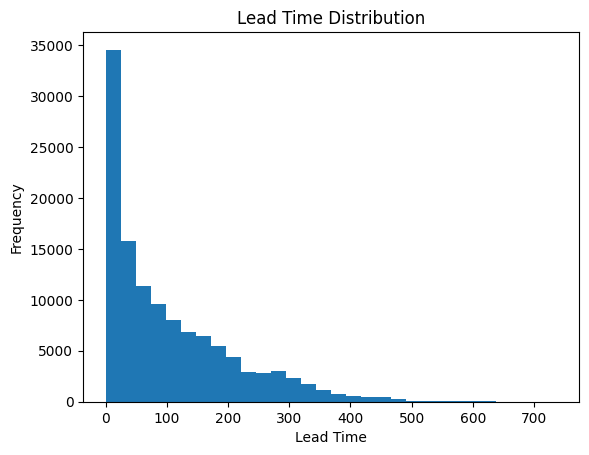

In [21]:
plt.hist(df['lead_time'], bins=30)

plt.title('Lead Time Distribution')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')
plt.show()

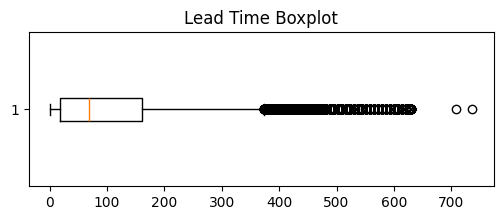

In [24]:
plt.figure(figsize=(6,2))

plt.boxplot(df['lead_time'], vert=False)

plt.title("Lead Time Boxplot")

plt.show()

### Interpretation
- Most bookings are made within a certain range of days before arrival.
- Long lead times may indicate early planners.
- Extremely large lead times should be investigated.
- right skewed

In [25]:
df['previous_cancellations'].describe()

count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64

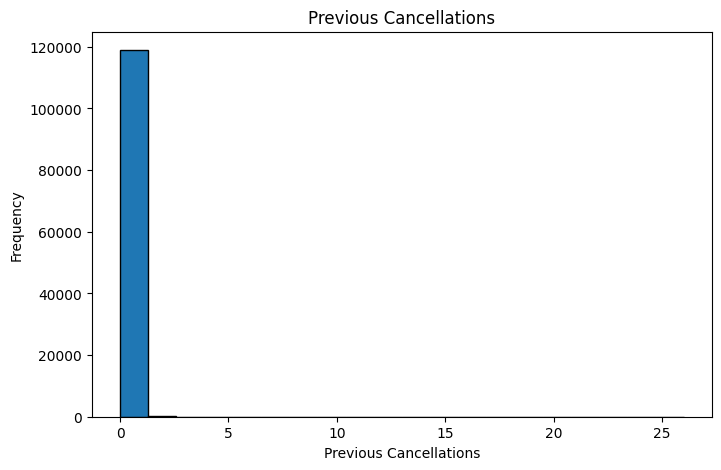

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df['previous_cancellations'], bins=20, edgecolor='black')

plt.title("Previous Cancellations")

plt.xlabel("Previous Cancellations")
plt.ylabel("Frequency")

plt.show()

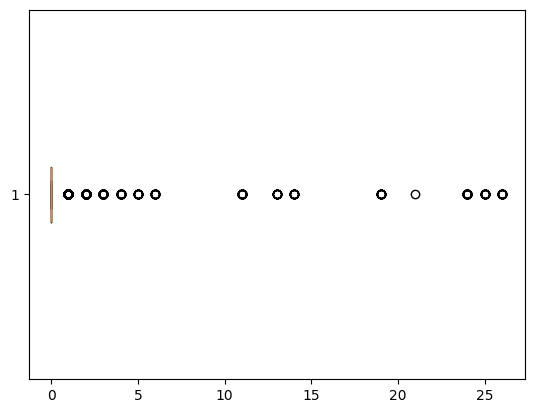

In [27]:
plt.boxplot(df['previous_cancellations'], vert=False)
plt.show()

In [28]:
df['previous_bookings_not_canceled'].describe()

count    119390.000000
mean          0.137097
std           1.497437
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          72.000000
Name: previous_bookings_not_canceled, dtype: float64

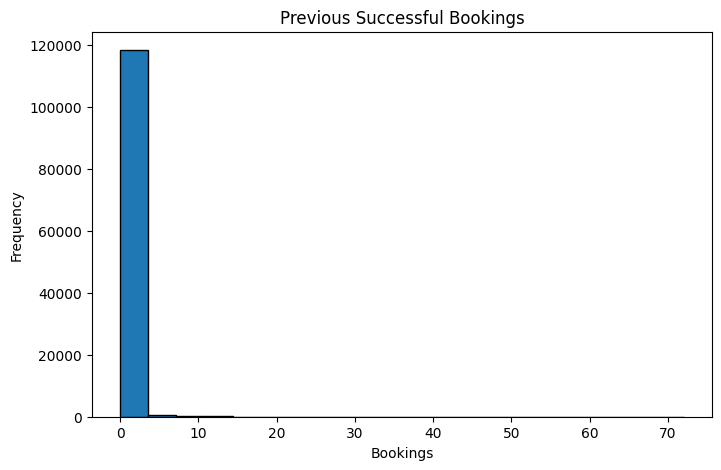

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df['previous_bookings_not_canceled'],
         bins=20,
         edgecolor='black')

plt.title("Previous Successful Bookings")

plt.xlabel("Bookings")
plt.ylabel("Frequency")

plt.show()

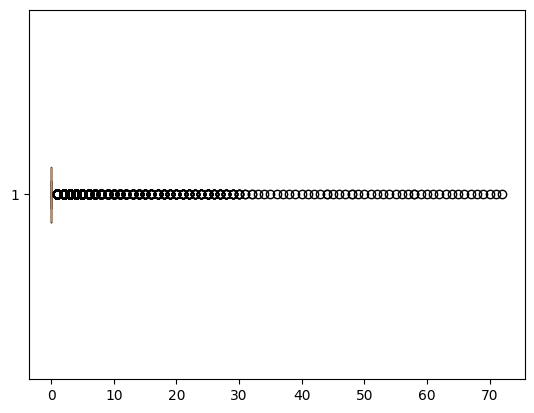

In [30]:
plt.boxplot(df['previous_bookings_not_canceled'],
            vert=False)

plt.show()

In [31]:
df['days_in_waiting_list'].describe()

count    119390.000000
mean          2.321149
std          17.594721
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64

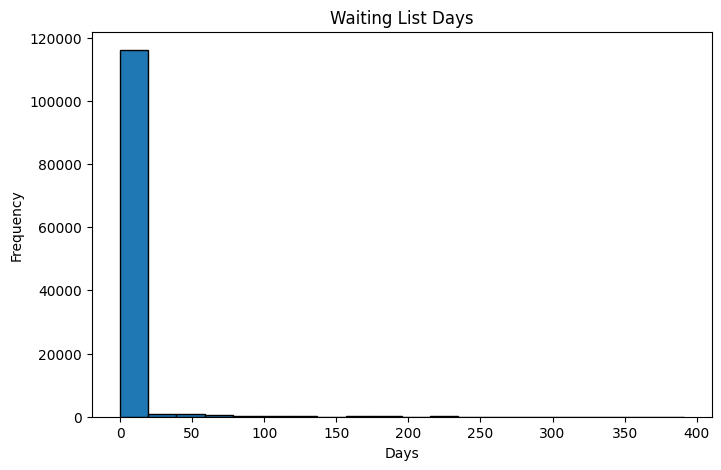

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df['days_in_waiting_list'],
         bins=20,
         edgecolor='black')

plt.title("Waiting List Days")

plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

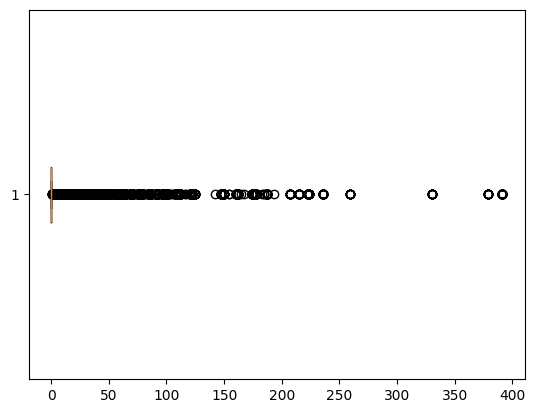

In [33]:
plt.boxplot(df['days_in_waiting_list'],
            vert=False)

plt.show()

In [34]:
df['booking_changes'].describe()

count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64

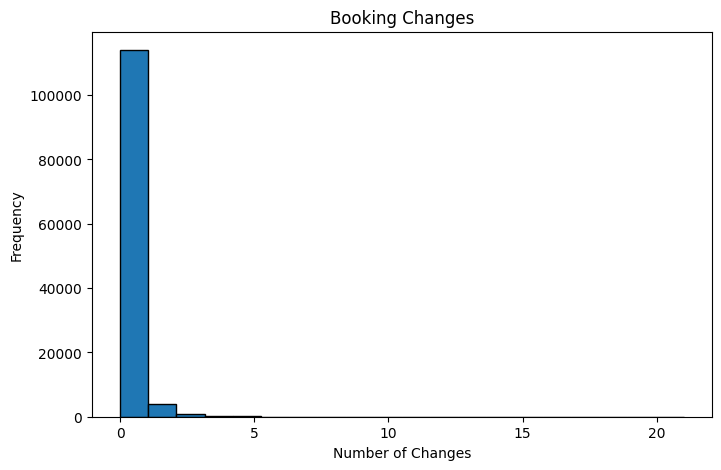

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df['booking_changes'],
         bins=20,
         edgecolor='black')

plt.title("Booking Changes")

plt.xlabel("Number of Changes")
plt.ylabel("Frequency")

plt.show()

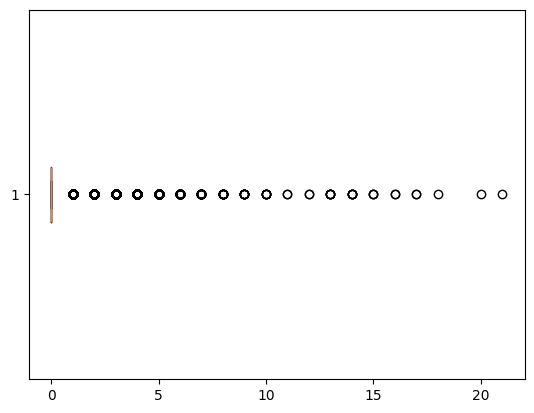

In [36]:
plt.boxplot(df['booking_changes'],
            vert=False)

plt.show()

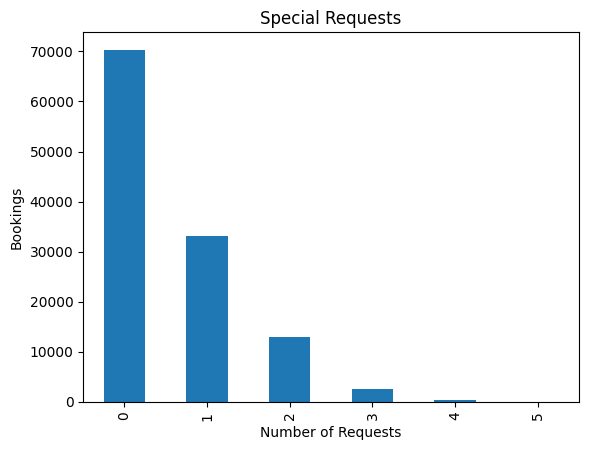

In [22]:
df['total_of_special_requests'].value_counts().sort_index().plot(kind='bar')

plt.title('Special Requests')
plt.xlabel('Number of Requests')
plt.ylabel('Bookings')
plt.show()

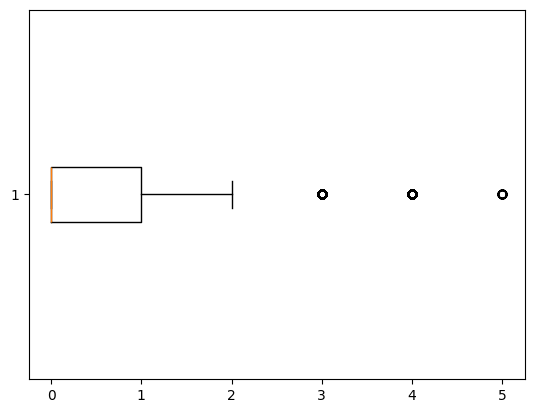

In [37]:
plt.boxplot(df['total_of_special_requests'],
            vert=False)

plt.show()

### Interpretation
Most customers make 0–2 special requests.
Very few customers request many special services.
Special requests may be linked to customer satisfaction.

## Bivariate Analysis

In [38]:
pd.crosstab(df['hotel'], df['is_canceled'])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


In [39]:
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index')*100

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


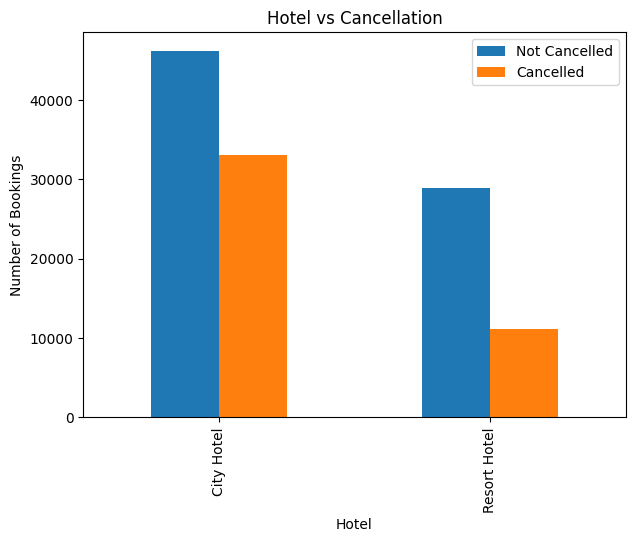

In [40]:
import matplotlib.pyplot as plt

pd.crosstab(df['hotel'], df['is_canceled']).plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Hotel vs Cancellation")
plt.xlabel("Hotel")
plt.ylabel("Number of Bookings")
plt.legend(["Not Cancelled","Cancelled"])

plt.show()

In [41]:
pd.crosstab(df['market_segment'], df['is_canceled'])

is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7714,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Undefined,0,2


In [42]:
pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index')*100

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Undefined,0.000000,100.000000


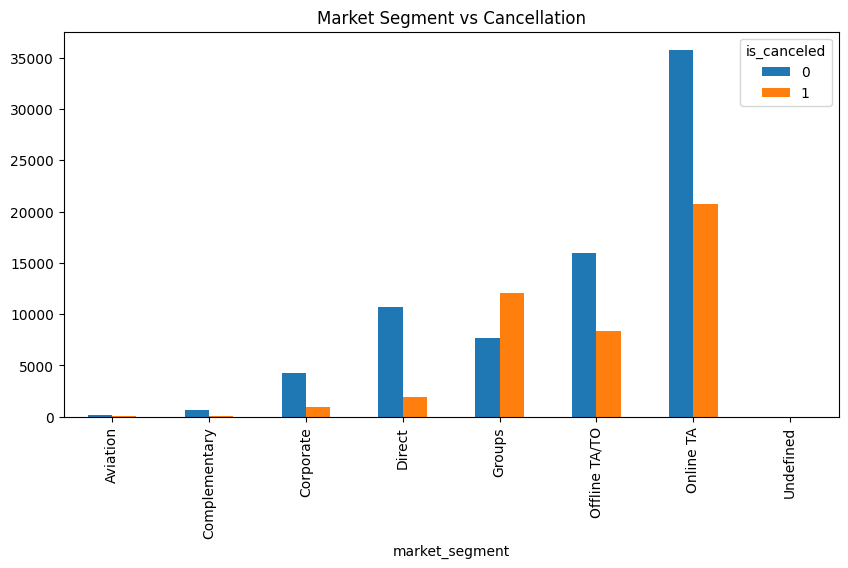

In [43]:
pd.crosstab(df['market_segment'], df['is_canceled']).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Market Segment vs Cancellation")

plt.show()

In [44]:
pd.crosstab(df['deposit_type'], df['is_canceled'])

is_canceled,0,1
deposit_type,,
No Deposit,74947,29694
Non Refund,93,14494
Refundable,126,36


In [45]:
pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index')*100

is_canceled,0,1
deposit_type,,
No Deposit,71.622978,28.377022
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


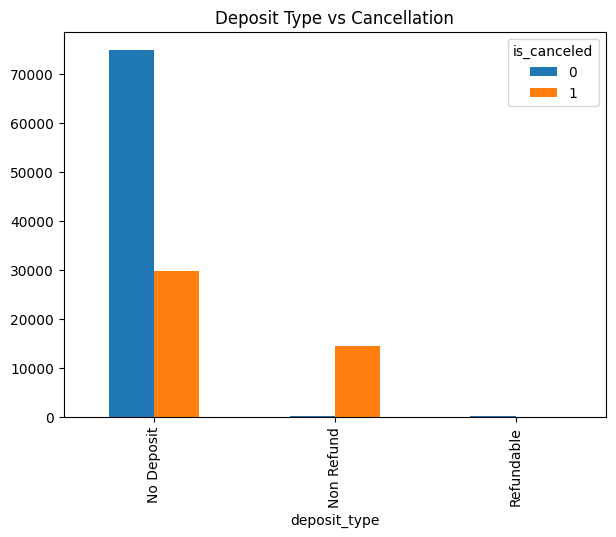

In [46]:
pd.crosstab(df['deposit_type'], df['is_canceled']).plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Deposit Type vs Cancellation")

plt.show()

In [47]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

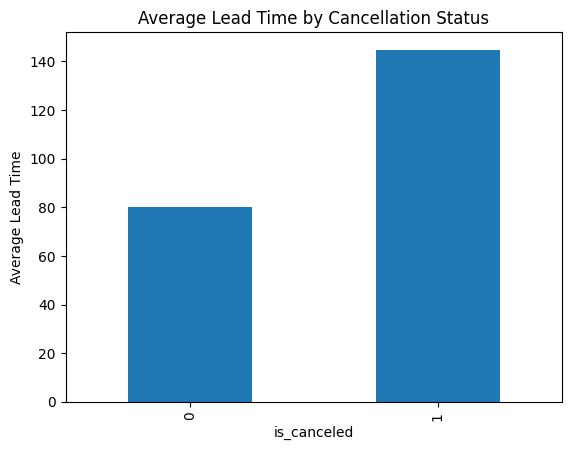

In [48]:
df.groupby('is_canceled')['lead_time'].mean().plot(
    kind='bar'
)

plt.title("Average Lead Time by Cancellation Status")
plt.ylabel("Average Lead Time")

plt.show()

In [49]:
df.groupby('is_canceled')['previous_cancellations'].mean()

is_canceled
0    0.015792
1    0.208348
Name: previous_cancellations, dtype: float64

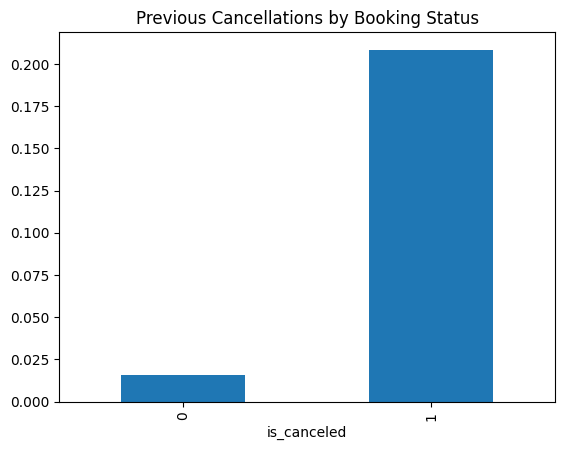

In [50]:
df.groupby('is_canceled')['previous_cancellations'].mean().plot(
    kind='bar'
)

plt.title("Previous Cancellations by Booking Status")

plt.show()

In [51]:
df.groupby('is_canceled')['previous_bookings_not_canceled'].mean()

is_canceled
0    0.202977
1    0.025122
Name: previous_bookings_not_canceled, dtype: float64

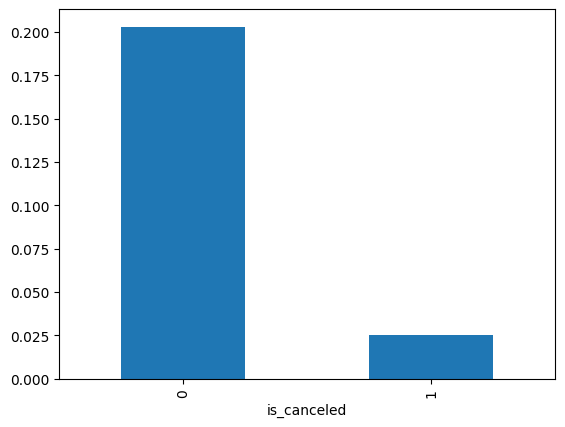

In [52]:
df.groupby('is_canceled')['previous_bookings_not_canceled'].mean().plot(
    kind='bar'
)

plt.show()

In [53]:
df.groupby('is_canceled')['booking_changes'].mean()

is_canceled
0    0.293364
1    0.098340
Name: booking_changes, dtype: float64

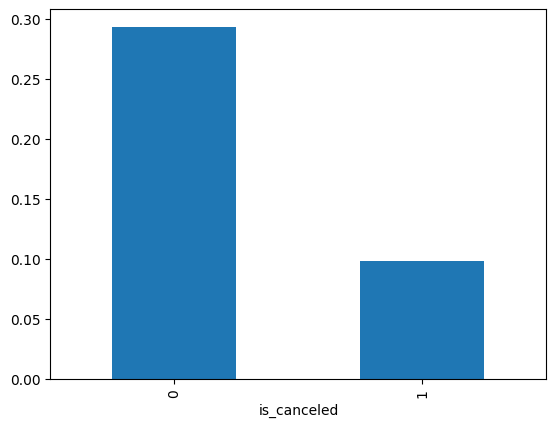

In [54]:
df.groupby('is_canceled')['booking_changes'].mean().plot(
    kind='bar'
)

plt.show()

In [55]:
df.groupby('is_canceled')['total_of_special_requests'].mean()

is_canceled
0    0.714060
1    0.328826
Name: total_of_special_requests, dtype: float64

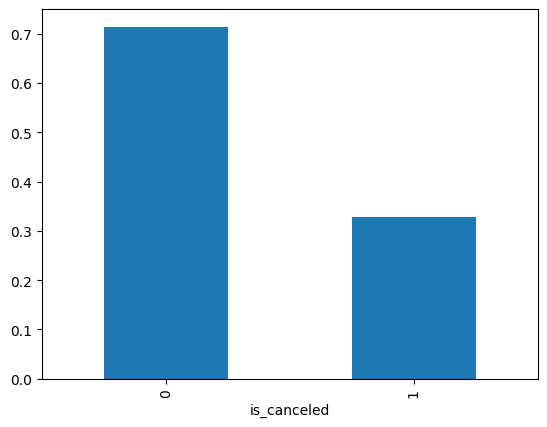

In [56]:
df.groupby('is_canceled')['total_of_special_requests'].mean().plot(
    kind='bar'
)

plt.show()

In [57]:
df.groupby('is_canceled')['days_in_waiting_list'].mean()

is_canceled
0    1.589868
1    3.564083
Name: days_in_waiting_list, dtype: float64

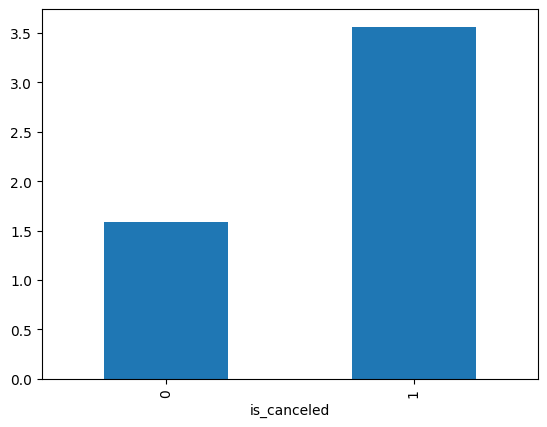

In [58]:
df.groupby('is_canceled')['days_in_waiting_list'].mean().plot(
    kind='bar'
)

plt.show()

## 1. Descriptive Statistics

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
previous_cancellations,119390.0,0.087118,0.844336,0.0,0.0,0.0,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.0,0.0,0.0,0.0,72.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.0,0.0,0.0,0.0,391.0
booking_changes,119390.0,0.221124,0.652306,0.0,0.0,0.0,0.0,21.0
total_of_special_requests,119390.0,0.571363,0.792798,0.0,0.0,0.0,1.0,5.0
is_canceled,119390.0,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0


In [60]:
df['lead_time'].skew()

np.float64(1.3465498727254264)

In [61]:
#Right-skewed lead time means most customers book relatively close to arrival, while a smaller group books far in advance.

In [62]:
df['lead_time'].kurt()

np.float64(1.696448848558545)

In [ ]:
#High kurtosis suggests more extreme booking behaviors.

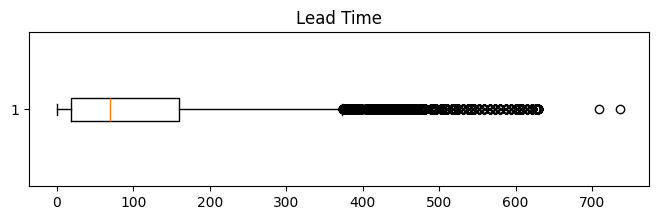

In [63]:

plt.figure(figsize=(8,2))

plt.boxplot(df['lead_time'],vert=False)

plt.title("Lead Time")

plt.show()

In [64]:
Q1=df['lead_time'].quantile(0.25)

Q3=df['lead_time'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df['lead_time']<lower)|(df['lead_time']>upper)]

print(outliers.shape)

(3005, 10)


In [65]:
corr=df.corr(numeric_only=True)

corr

,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
lead_time,1.000000,0.086042,-0.073548,0.170084,0.000149,-0.095712,0.293123
previous_cancellations,0.086042,1.000000,0.152728,0.005929,-0.026993,-0.048384,0.110133
previous_bookings_not_canceled,-0.073548,0.152728,1.000000,-0.009397,0.011608,0.037824,-0.057358
days_in_waiting_list,0.170084,0.005929,-0.009397,1.000000,-0.011634,-0.082730,0.054186
booking_changes,0.000149,-0.026993,0.011608,-0.011634,1.000000,0.052833,-0.144381
total_of_special_requests,-0.095712,-0.048384,0.037824,-0.082730,0.052833,1.000000,-0.234658
is_canceled,0.293123,0.110133,-0.057358,0.054186,-0.144381,-0.234658,1.000000


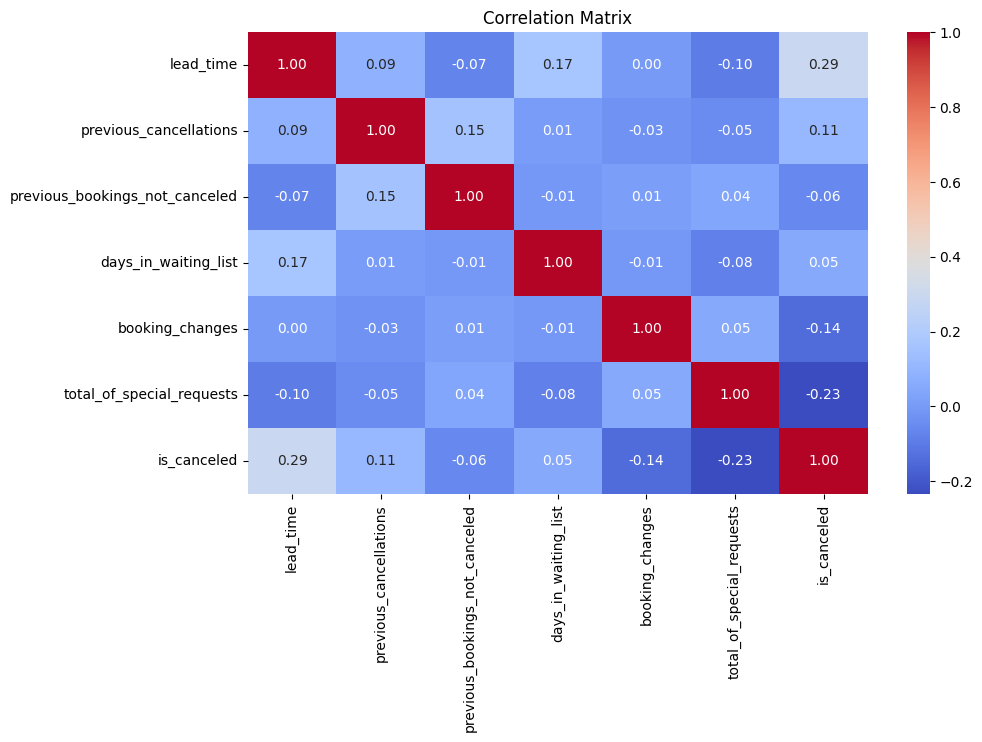

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

In [67]:
columns=[
'lead_time',
'previous_cancellations',
'previous_bookings_not_canceled',
'days_in_waiting_list',
'booking_changes',
'total_of_special_requests'
]

for col in columns:
    print(col)
    print("Mean :",df[col].mean())
    print("Median :",df[col].median())
    print("Skewness :",df[col].skew())
    print("-"*40)

lead_time
Mean : 104.01141636652986
Median : 69.0
Skewness : 1.3465498727254264
----------------------------------------
previous_cancellations
Mean : 0.08711784906608594
Median : 0.0
Skewness : 24.458048723119287
----------------------------------------
previous_bookings_not_canceled
Mean : 0.13709690928888515
Median : 0.0
Skewness : 23.539799952843467
----------------------------------------
days_in_waiting_list
Mean : 2.321149174972778
Median : 0.0
Skewness : 11.944353446438395
----------------------------------------
booking_changes
Mean : 0.22112404724013737
Median : 0.0
Skewness : 6.000270054409322
----------------------------------------
total_of_special_requests
Mean : 0.5713627607002262
Median : 0.0
Skewness : 1.3491893774222594
----------------------------------------
